In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\merli\OneDrive\Desktop\archive\ai_dependency_career_anxiety_students.csv")

In [4]:
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  object 
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  object 
 3   degree_type                      15000 non-null  object 
 4   stream                           15000 non-null  object 
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  object 
 7   urban_or_rural                   15000 non-null  object 
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  object 
 10  uses_ai_for_assignments          15000 non-null  object 
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_scor

In [6]:
df.isnull().sum()

student_id                            0
age                                   0
gender                                0
degree_type                           0
stream                                0
year_of_study                         0
college_tier                          0
urban_or_rural                        0
daily_ai_tool_usage_hrs               0
primary_ai_tools_used              3215
uses_ai_for_assignments               0
ai_replaces_own_thinking_score        0
ai_dependency_score                   0
placement_anxiety_score               0
fear_of_job_loss_to_ai                0
career_clarity_score                  0
internship_experience                 0
weekly_job_application_count          0
resume_confidence_score               0
interview_anxiety_score               0
daily_study_hours                     0
self_learning_hours_per_week        233
skill_development_courses_taken       0
social_media_hrs_per_day            210
sleep_hours                         203


In [7]:
df = df.drop_duplicates()

In [8]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


In [10]:
df["overall_career_readiness_score"].mean()

np.float64(5.998019333333334)

In [11]:
df["overall_career_readiness_score"].median()

6.0

In [12]:
df["overall_career_readiness_score"].std()

1.5939816525899746

In [13]:
df["overall_career_readiness_score"].quantile([0.25,0.50,0.75])

0.25    4.90
0.50    6.00
0.75    7.12
Name: overall_career_readiness_score, dtype: float64

In [14]:
df["overall_career_readiness_score"].quantile(0.90)

np.float64(8.06)

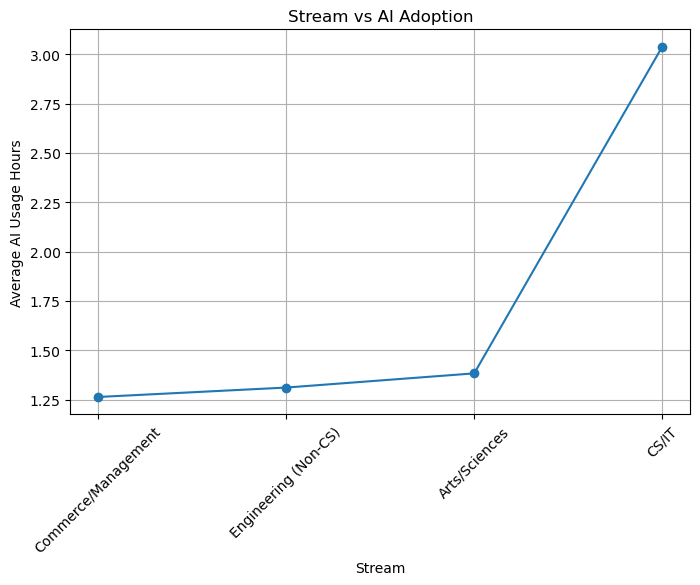

In [21]:
import matplotlib.pyplot as plt

stream_adoption = df.groupby("stream")["daily_ai_tool_usage_hrs"].mean().sort_values()

plt.figure(figsize=(8,5))
plt.plot(stream_adoption.index,
         stream_adoption.values,
         marker='o')

plt.title("Stream vs AI Adoption")
plt.xlabel("Stream")
plt.ylabel("Average AI Usage Hours")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

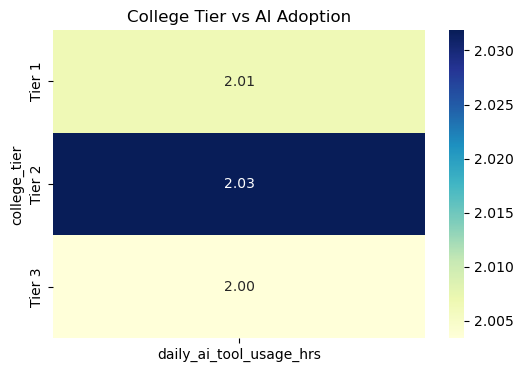

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.pivot_table(
    df,
    values="daily_ai_tool_usage_hrs",
    index="college_tier",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data,
            annot=True,
            cmap="YlGnBu",
            fmt=".2f")

plt.title("College Tier vs AI Adoption")
plt.show()

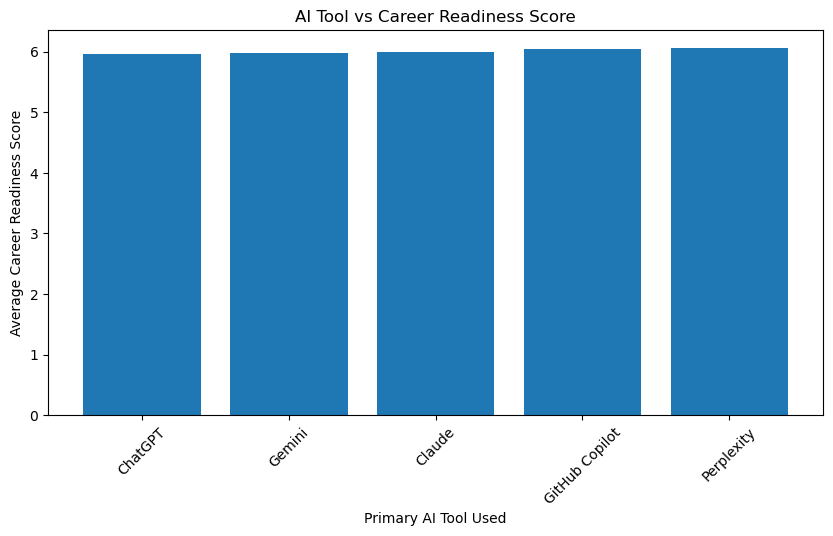

In [23]:
import matplotlib.pyplot as plt

tool_satisfaction = df.groupby("primary_ai_tools_used")[
    "overall_career_readiness_score"
].mean().sort_values()

plt.figure(figsize=(10,5))
plt.bar(tool_satisfaction.index, tool_satisfaction.values)

plt.title("AI Tool vs Career Readiness Score")
plt.xlabel("Primary AI Tool Used")
plt.ylabel("Average Career Readiness Score")
plt.xticks(rotation=45)

plt.show()

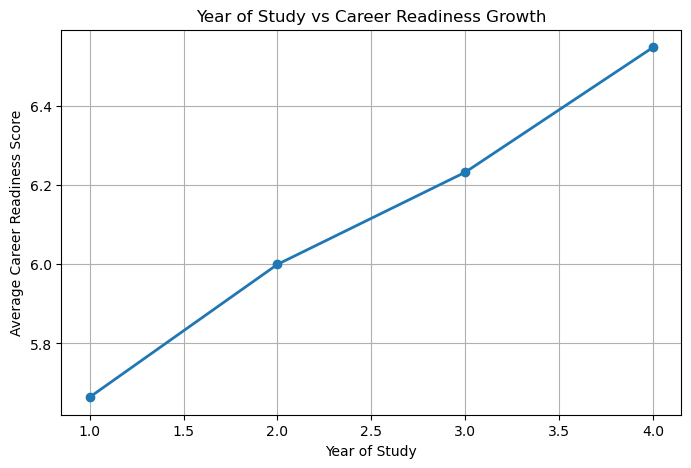

In [24]:
import matplotlib.pyplot as plt

growth_data = df.groupby("year_of_study")[
    "overall_career_readiness_score"
].mean()

plt.figure(figsize=(8,5))
plt.plot(
    growth_data.index,
    growth_data.values,
    marker='o',
    linewidth=2
)

plt.title("Year of Study vs Career Readiness Growth")
plt.xlabel("Year of Study")
plt.ylabel("Average Career Readiness Score")
plt.grid(True)

plt.show()

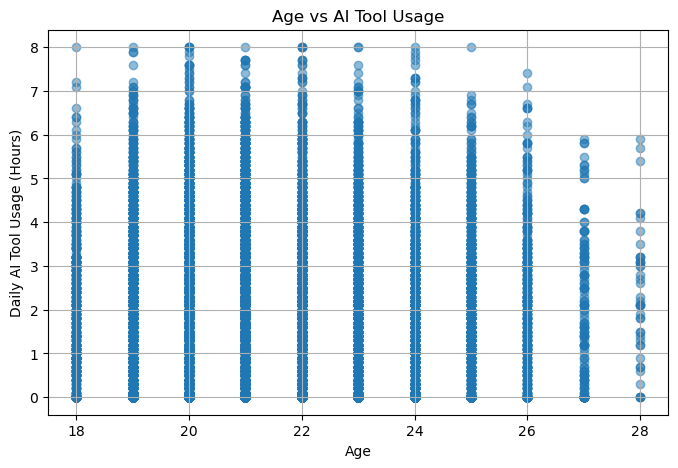

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["age"],
    df["daily_ai_tool_usage_hrs"],
    alpha=0.5
)

plt.title("Age vs AI Tool Usage")
plt.xlabel("Age")
plt.ylabel("Daily AI Tool Usage (Hours)")
plt.grid(True)

plt.show()

In [26]:
correlation = df["daily_ai_tool_usage_hrs"].corr(
    df["overall_career_readiness_score"]
)

print("Correlation:", correlation)

Correlation: -0.02038407835604804


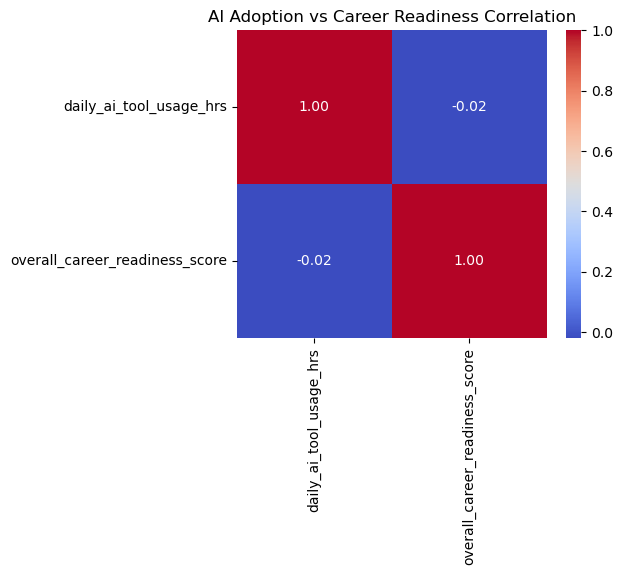

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = df[[
    "daily_ai_tool_usage_hrs",
    "overall_career_readiness_score"
]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("AI Adoption vs Career Readiness Correlation")
plt.show()

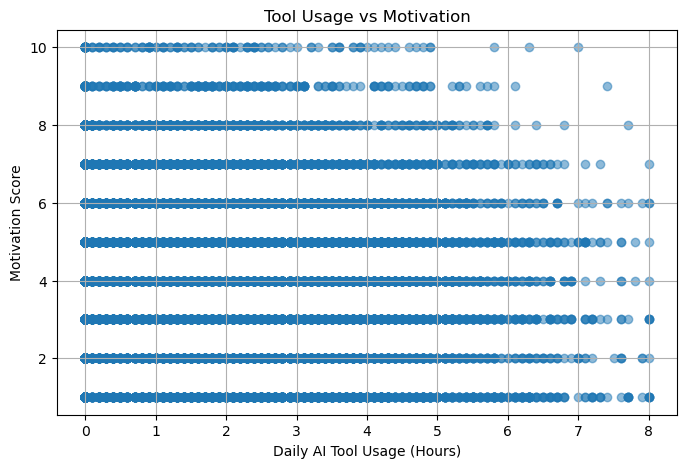

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["daily_ai_tool_usage_hrs"],
    df["motivation_score"],
    alpha=0.5
)

plt.title("Tool Usage vs Motivation")
plt.xlabel("Daily AI Tool Usage (Hours)")
plt.ylabel("Motivation Score")
plt.grid(True)

plt.show()

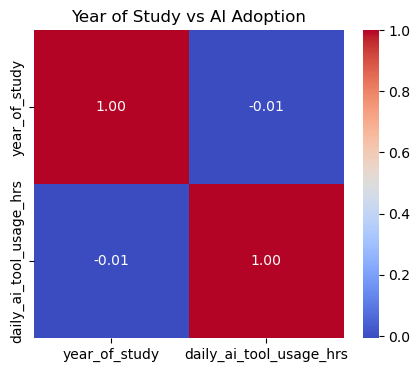

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = df[[
    "year_of_study",
    "daily_ai_tool_usage_hrs"
]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Year of Study vs AI Adoption")
plt.show()

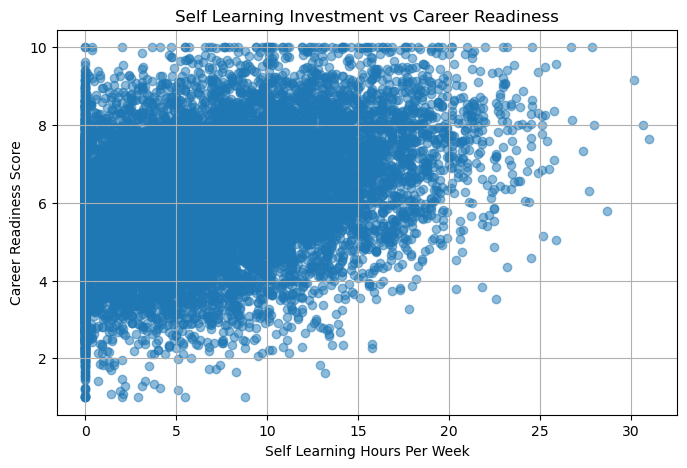

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["self_learning_hours_per_week"],
    df["overall_career_readiness_score"],
    alpha=0.5
)

plt.title("Self Learning Investment vs Career Readiness")
plt.xlabel("Self Learning Hours Per Week")
plt.ylabel("Career Readiness Score")
plt.grid(True)

plt.show()

In [31]:
from scipy.stats import f_oneway

tier1 = df[df["college_tier"]=="Tier 1"]["daily_ai_tool_usage_hrs"]
tier2 = df[df["college_tier"]=="Tier 2"]["daily_ai_tool_usage_hrs"]
tier3 = df[df["college_tier"]=="Tier 3"]["daily_ai_tool_usage_hrs"]

f_stat, p_value = f_oneway(tier1, tier2, tier3)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 0.44090792402148216
P-Value: 0.6434602908349845


         Segment Satisfaction_Category ROI_Category
0   Slow Adopter   Normal Satisfaction      Low ROI
1   Slow Adopter   Normal Satisfaction      Low ROI
2  Early Adopter   Normal Satisfaction   Medium ROI
3  Early Adopter   Normal Satisfaction   Medium ROI
4  Early Adopter   Normal Satisfaction   Medium ROI

AI Segments:
Segment
Slow Adopter     7982
Early Adopter    7018
Name: count, dtype: int64

Satisfaction Categories:
Satisfaction_Category
Normal Satisfaction    15000
Name: count, dtype: int64

ROI Categories:
ROI_Category
Low ROI       7982
Medium ROI    7018
Name: count, dtype: int64


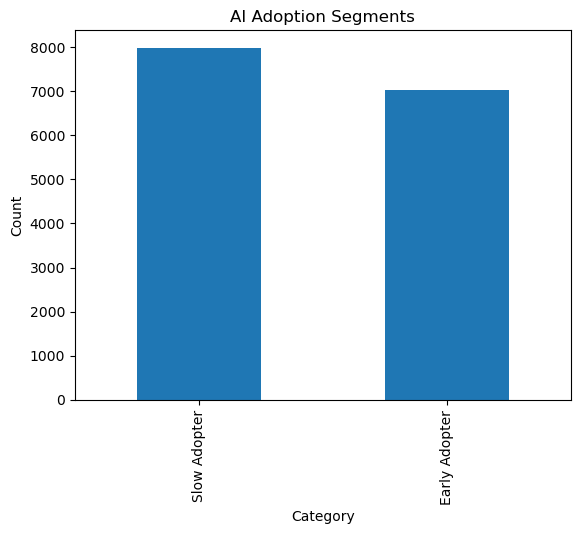

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

def categorize(row):

    # AI Adoption Segment
    if row["daily_ai_tool_usage_hrs"] >= 4 and row["overall_career_readiness_score"] >= 80:
        segment = "AI Leader"
    elif row["daily_ai_tool_usage_hrs"] >= 2:
        segment = "Early Adopter"
    else:
        segment = "Slow Adopter"

    # Satisfaction Category
    satisfaction = "High Satisfaction" if row["overall_career_readiness_score"] >= 80 else "Normal Satisfaction"

    # ROI Category
    if row["daily_ai_tool_usage_hrs"] >= 4 and row["overall_career_readiness_score"] >= 80:
        roi = "High ROI"
    elif row["daily_ai_tool_usage_hrs"] >= 2:
        roi = "Medium ROI"
    else:
        roi = "Low ROI"

    return pd.Series([segment, satisfaction, roi])

df[["Segment", "Satisfaction_Category", "ROI_Category"]] = df.apply(
    categorize,
    axis=1
)

print(df[["Segment", "Satisfaction_Category", "ROI_Category"]].head())

print("\nAI Segments:")
print(df["Segment"].value_counts())

print("\nSatisfaction Categories:")
print(df["Satisfaction_Category"].value_counts())

print("\nROI Categories:")
print(df["ROI_Category"].value_counts())

df["Segment"].value_counts().plot(kind="bar")
plt.title("AI Adoption Segments")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()